In [8]:
import sys
import pandas as pd
from pathlib import Path


def find_experiment_directory(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        direct = candidate / "utils.py"
        nested = candidate / "notebooks/illustrating_the_theorem/utils.py"
        if direct.is_file():
            return direct.parent
        if nested.is_file():
            return nested.parent
    raise FileNotFoundError("Could not locate illustrating_the_theorem/utils.py.")


EXPERIMENT_DIRECTORY = find_experiment_directory()
if str(EXPERIMENT_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIRECTORY))

In [9]:
sweep_results = pd.read_csv(
    EXPERIMENT_DIRECTORY 
    / "v2_log_volume_ratio_sweep_ot_10000_mc_10000_lazy_exact.csv"
)

In [10]:
sweep_summary = (
    sweep_results.groupby(["dimension", "k"])["log_volume_ratio"]
    .agg(
        n_seeds="count",
        mean="mean",
        standard_deviation="std",
        median="median",
        minimum="min",
        maximum="max",
    )
    .reset_index()
)
display(sweep_summary)

,dimension,k,n_seeds,mean,standard_deviation,median,minimum,maximum
0,2,2.0,10,-0.010748,0.016471,-0.010336,-0.044040,0.013400
1,2,4.0,10,-0.013835,0.016296,-0.015370,-0.042833,0.014997
2,2,8.0,10,-0.017404,0.017506,-0.018489,-0.048009,0.014854
3,2,16.0,10,-0.022323,0.015631,-0.023356,-0.047003,0.006658
4,2,32.0,10,-0.029331,0.017434,-0.031039,-0.059088,0.000987
5,2,64.0,10,-0.037647,0.018571,-0.040546,-0.072051,-0.003150
6,4,2.0,10,-1.228485,0.075759,-1.244660,-1.317594,-1.107595
7,4,4.0,10,-1.232240,0.081013,-1.250111,-1.333518,-1.093594
8,4,8.0,10,-1.301619,0.115363,-1.300024,-1.437071,-1.065969
9,4,16.0,10,-1.363830,0.110054,-1.383491,-1.500542,-1.190540


KeyError: 'mean'

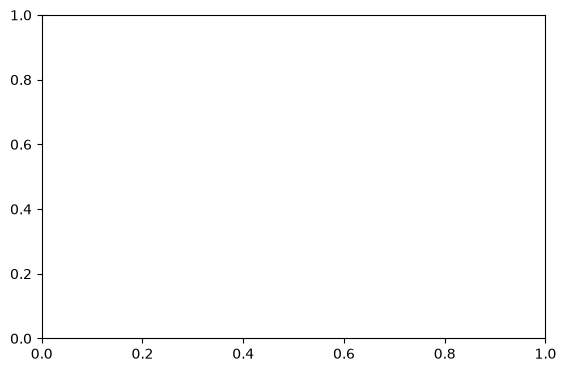

In [21]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = sweep_summary.copy()

sweep_results["scaled_log_volume_gap"] = (
    -sweep_results["log_volume_ratio"]
    / sweep_results["dimension"]
)

scaled_summary = (
    sweep_results
    .groupby(["dimension", "k"])["scaled_log_volume_gap"]
    .agg(
        n_seeds="count",
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    )
    .reset_index()
)
# Dimension-normalized log-volume gap:
# (1 / d) * log(Vol(C) / Vol(HDR))
plot_df["scaled_mean"] = -plot_df["mean"] / plot_df["dimension"]
plot_df["scaled_std"] = (
    plot_df["standard_deviation"] / plot_df["dimension"]
)
fig, ax = plt.subplots(figsize=(6.5, 4.2))

for dimension, group in scaled_summary.groupby("dimension"):
    group = group.sort_values("k")

    ax.plot(
        group["k"],
        group["mean"],
        marker="o",
        linewidth=1.8,
        markersize=5,
        label=fr"$d={dimension}$",
    )

    ax.fill_between(
        group["k"],
        group["mean"] - group["standard_deviation"],
        group["mean"] + group["standard_deviation"],
        alpha=0.15,
    )

ax.axhline(0, linestyle="--", linewidth=1, alpha=0.7)

ax.set_xscale("log", base=2)
ax.set_xticks([2, 4, 8, 16, 32, 64])
ax.set_xticklabels([2, 4, 8, 16, 32, 64])

ax.set_xlabel(r"Condition number $k$")
ax.set_ylabel(
    r"$\frac{1}{d}\log\frac{\mathrm{Vol}(C_{1-\alpha})}"
    r"{\mathrm{Vol}(\mathrm{HDR}_{1-\alpha})}$"
)

ax.legend(title=r"$d$", frameon=False, ncol=2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()

In [22]:
scaled_summary

,dimension,k,n_seeds,median,q25,q75
0,2,2.0,10,0.005168,0.001924,0.009179
1,2,4.0,10,0.007685,0.003248,0.011307
2,2,8.0,10,0.009244,0.005276,0.013154
3,2,16.0,10,0.011678,0.007326,0.015783
4,2,32.0,10,0.015519,0.010745,0.018557
5,2,64.0,10,0.020273,0.015320,0.021782
6,4,2.0,10,0.311165,0.294281,0.323089
7,4,4.0,10,0.312528,0.293973,0.322306
8,4,8.0,10,0.325006,0.313345,0.350520
9,4,16.0,10,0.345873,0.316996,0.365079


In [9]:
( 1 / dim ) * log( Vol(C_OT) / Vol(HDR) )

NameError: name 'dim' is not defined

In [13]:
sweep_results["scaled_log_volume_gap"].tail(50)

310    0.541057
311    0.534443
312    0.542326
313    0.535262
314    0.553308
315    0.574598
316    0.578300
317    0.546955
318    0.524674
319    0.517473
320    0.536719
321    0.536582
322    0.545474
323    0.533302
324    0.550946
325    0.551756
326    0.553882
327    0.534018
328    0.520796
329    0.527386
330    0.530823
331    0.536129
332    0.542359
333    0.536681
334    0.552107
335    0.556270
336    0.559143
337    0.539132
338    0.521770
339    0.522409
340    0.543540
341    0.560933
342    0.542439
343    0.546640
344    0.558870
345    0.553693
346    0.564896
347    0.551001
348    0.536078
349    0.544303
350    0.545335
351    0.559083
352    0.541078
353    0.546620
354    0.557777
355    0.550444
356    0.562961
357    0.541785
358    0.530582
359    0.543911
Name: scaled_log_volume_gap, dtype: float64